# Belief-Driven Coding Agent (Minimal Prototype)

**Objective:** Build a simple coding agent that iteratively writes code to pass unknown unit tests,
guided by test feedback it can observe but test source it cannot see.

**Components:**
1. Coding Agent (open-weights LLM) : receives a task, generates code
2. Hidden Test Harness : runs the agent's code against secret unit tests, returns only pass/fail + error messages
3. LLM-as-Judge : evaluates the agent's submission: compilation status, test pass rate, qualitative analysis

This is supposed to mirror the belief-planning loop in the OpenTAMP domain:

- The agent's code generation -> the continuous/motion layer
- Test feedback (pass/fail, no source) -> partial observations (like observing obstacle locations)
- The retry loop -> backtracking refinement (symbolic replanning after continuous failure)
- The judge -> goal predicate evaluation (like checking `RobotAtTarget`)

Later, this architecture will be formalized into OpenTAMP's hierarchical planning framework as part of the SWE-TAMP domain.


In [ ]:
!pip install transformers accelerate torch -q

In [ ]:
# ── Imports ──
import subprocess
import tempfile
import os
import textwrap

## Step 1: Define the Task

This is the only information the agent receives. It describes what function to write,
including the expected behavior. Crucially, it says nothing about the specific test cases
that will be used to evaluate the solution.

This separation is key: just as a robot doesn't know the exact obstacle positions before
observing, the agent doesn't know the exact tests before submitting code and getting feedback.

In [ ]:
# ── Task Prompt ──
# This is what the coding agent sees. It defines the problem but NOT the test cases.

TASK_PROMPT = """Write a Python function called fizzbuzz(n) that returns a list of strings
for numbers 1 to n.

Rules:
- If the number is divisible by 3, the string should be "Fizz"
- If divisible by 5, "Buzz"
- If divisible by both 3 and 5, "FizzBuzz"
- Otherwise, the string representation of the number

Return ONLY the function definition, no examples or test code."""

## Step 2: Hidden Tests

These unit tests are never shown to the agent. They run in a sandboxed subprocess.
The agent only sees the output: how many tests passed, which ones failed, and error messages.

This is analogous to the **environment** in OpenTAMP. The agent can take actions (submit code)
and receive observations (test results), but cannot directly inspect the environment's internals
(test source code).

In [ ]:
# ── Hidden Unit Tests ──
# The agent CANNOT see this code. It only sees the stdout/stderr after execution.

HIDDEN_TESTS = """\
import sys

results = []

# ── Try importing the agent's solution ──
try:
    from solution import fizzbuzz
    results.append(("import", True, ""))
except Exception as e:
    results.append(("import", False, str(e)))
    passed = sum(1 for _, p, _ in results if p)
    print(f"PASSED: {passed}/{len(results)}")
    for name, p, msg in results:
        status = "PASS" if p else "FAIL"
        print(f"  [{status}] {name}: {msg}")
    sys.exit(1)

# ── Test runner ──
def run_test(name, expected, actual_fn):
    try:
        actual = actual_fn()
        assert actual == expected, f"expected {expected}, got {actual}"
        results.append((name, True, ""))
    except AssertionError as e:
        results.append((name, False, str(e)))
    except Exception as e:
        results.append((name, False, str(e)))

# ── Individual test cases ──
run_test("basic_1",        ["1"],                                    lambda: fizzbuzz(1))
run_test("fizz_3",         ["1", "2", "Fizz"],                      lambda: fizzbuzz(3))
run_test("buzz_5",         ["1", "2", "Fizz", "4", "Buzz"],         lambda: fizzbuzz(5))
run_test("fizzbuzz_15",    "FizzBuzz",                               lambda: fizzbuzz(15)[-1])
run_test("length_20",      20,                                       lambda: len(fizzbuzz(20)))
run_test("types_are_str",  True,                                     lambda: all(isinstance(x, str) for x in fizzbuzz(5)))
run_test("no_fizz_at_1",   "1",                                      lambda: fizzbuzz(1)[0])
run_test("fizzbuzz_at_30", "FizzBuzz",                               lambda: fizzbuzz(30)[29])

# ── Summary ──
passed = sum(1 for _, p, _ in results if p)
total = len(results)
print(f"PASSED: {passed}/{total}")
for name, p, msg in results:
    status = "PASS" if p else "FAIL"
    print(f"  [{status}] {name}: {msg}")
if passed < total:
    sys.exit(1)
"""

## Step 3: The Test Harness

This function takes the agent's code as a string, writes it to a temporary directory,
runs the hidden tests in a **sandboxed subprocess**, and returns a structured result.

The agent never touches the test file. It only sees the dictionary that comes back:
- `stdout`: the test output (e.g., "PASSED: 6/8, [FAIL] fizz_3: ...")
- `stderr`: any Python errors or tracebacks
- `exit_code`: 0 if all tests passed, 1 otherwise
- `all_passed`: boolean convenience flag

In [ ]:
# ── Test Harness ──
# Runs the agent's code against hidden tests in an isolated subprocess.
# Returns structured feedback — never exposes test source.

def run_hidden_tests(agent_code: str) -> dict:
    """
    Execute agent's code against the hidden test suite.

    Args:
        agent_code: The Python source code submitted by the agent.

    Returns:
        dict with keys: stdout, stderr, exit_code, all_passed
    """
    with tempfile.TemporaryDirectory() as tmpdir:
        # Write the agent's code as solution.py
        solution_path = os.path.join(tmpdir, "solution.py")
        with open(solution_path, "w") as f:
            f.write(agent_code)

        # Write the hidden tests (agent never sees this file)
        test_path = os.path.join(tmpdir, "test_hidden.py")
        with open(test_path, "w") as f:
            f.write(HIDDEN_TESTS)

        # Run in subprocess — fully sandboxed
        try:
            result = subprocess.run(
                ["python", "test_hidden.py"],
                cwd=tmpdir,
                capture_output=True,
                text=True,
                timeout=10
            )
            return {
                "stdout": result.stdout,
                "stderr": result.stderr,
                "exit_code": result.returncode,
                "all_passed": result.returncode == 0
            }
        except subprocess.TimeoutExpired:
            return {
                "stdout": "",
                "stderr": "TIMEOUT: Code took longer than 10 seconds.",
                "exit_code": -1,
                "all_passed": False
            }

## Sanity Check

Verify the harness works by passing it a deliberately wrong solution
and then a correct one.

In [ ]:
# ── Sanity check: bad solution ──
bad_code = "def fizzbuzz(n):\n    return ['wrong'] * n"
result = run_hidden_tests(bad_code)
print("=== BAD SOLUTION ===")
print(result["stdout"])
print(result["stderr"][:200] if result["stderr"] else "(no errors)")
print(f"All passed: {result['all_passed']}\n")

# ── Sanity check: correct solution ──
good_code = textwrap.dedent("""\
    def fizzbuzz(n):
        out = []
        for i in range(1, n + 1):
            if i % 15 == 0:
                out.append("FizzBuzz")
            elif i % 3 == 0:
                out.append("Fizz")
            elif i % 5 == 0:
                out.append("Buzz")
            else:
                out.append(str(i))
        return out
""")
result = run_hidden_tests(good_code)
print("=== GOOD SOLUTION ===")
print(result["stdout"])
print(f"All passed: {result['all_passed']}")

=== BAD SOLUTION ===
PASSED: 3/9
  [PASS] import: 
  [FAIL] basic_1: expected ['1'], got ['wrong']
  [FAIL] fizz_3: expected ['1', '2', 'Fizz'], got ['wrong', 'wrong', 'wrong']
  [FAIL] buzz_5: expected ['1', '2', 'Fizz', '4', 'Buzz'], got ['wrong', 'wrong', 'wrong', 'wrong', 'wrong']
  [FAIL] fizzbuzz_15: expected FizzBuzz, got wrong
  [PASS] length_20: 
  [PASS] types_are_str: 
  [FAIL] no_fizz_at_1: expected 1, got wrong
  [FAIL] fizzbuzz_at_30: expected FizzBuzz, got wrong

(no errors)
All passed: False

=== GOOD SOLUTION ===
PASSED: 9/9
  [PASS] import: 
  [PASS] basic_1: 
  [PASS] fizz_3: 
  [PASS] buzz_5: 
  [PASS] fizzbuzz_15: 
  [PASS] length_20: 
  [PASS] types_are_str: 
  [PASS] no_fizz_at_1: 
  [PASS] fizzbuzz_at_30: 

All passed: True


## Step 4: Load the Coding Agent (LLM)

We use **DeepSeek-Coder-6.7B-Instruct** as the coding agent. This model fits
comfortably on a free Colab T4 GPU (16GB VRAM) and is specifically trained for
code generation and instruction-following.

The model plays the role of the continuous/motion layer in the OpenTAMP analogy, i.e.
it takes an action (writes code), receives an observation (test results), and
revises its approach on failure.

In [ ]:
# ── Load the coding agent LLM ──
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "deepseek-ai/deepseek-coder-6.7b-instruct"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

print("Loading model (this takes 1-2 minutes on T4)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
print(f"Model loaded on {model.device}")

Loading tokenizer...


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading model (this takes 1-2 minutes on T4)...


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

Model loaded on cuda:0


## Step 5: The Agent Generation Function

This function sends a prompt to the LLM and extracts the Python code from its response.

Key design choice: we ask the model to wrap its code in \`\`\`python ... \`\`\` fences,
then parse those out. This keeps the extraction robust even if the model adds
explanatory text around the code.

In [ ]:
# ── Agent code generation ──
import re

def generate_code(prompt: str, max_new_tokens: int = 512) -> str:
    """
    Send a prompt to the coding agent and extract the Python code block.
    """
    messages = [{"role": "user", "content": prompt}]

    # Step 1: get formatted text (not tensors)
    input_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    # Step 2: tokenize separately
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    code_match = re.search(r"```python\s*\n(.*?)```", response, re.DOTALL)
    if code_match:
        return code_match.group(1).strip()

    code_match = re.search(r"```\s*\n(.*?)```", response, re.DOTALL)
    if code_match:
        return code_match.group(1).strip()

    return response.strip()

## Step 6: The Agent Loop (Refinement Cycle)

This is the iterative refinement loop.

1. First attempt: Send the task prompt to the agent, get code back
2. Test: Run the code against hidden tests
3. If tests fail: Append the test feedback to the conversation and ask the agent to fix it
4. Repeat until all tests pass or we hit a max number of attempts

This is meant to be somewhat analogous to OpenTAMP's `backtrack_plan_recursive`:
- Each code submission = a continuous-layer refinement attempt
- Test failure feedback = a constraint fed back to the symbolic layer
- Each retry = a replan with updated information

We log every attempt so we can inspect the agent's trajectory afterward.

In [ ]:
# ── Agent Loop ──

def run_agent_loop(task: str, max_attempts: int = 5) -> list:
    """
    Run the coding agent in a feedback loop against hidden tests.

    Args:
        task: The task description shown to the agent.
        max_attempts: Maximum refinement attempts before giving up.

    Returns:
        List of dicts, one per attempt, containing:
        - attempt: attempt number
        - code: the agent's submitted code
        - test_result: the harness output
        - prompt: the full prompt sent to the agent
    """
    history = []
    prompt = f"""You are a Python coding assistant. Write code to solve this task.
Return ONLY a Python code block wrapped in ```python ... ``` fences.

TASK:
{task}"""

    for attempt in range(1, max_attempts + 1):
        print(f"\n{'='*60}")
        print(f"  ATTEMPT {attempt}/{max_attempts}")
        print(f"{'='*60}")

        # ── Agent generates code ──
        print("Agent is writing code...")
        code = generate_code(prompt)
        print(f"Code generated ({len(code)} chars)")

        # ── Run hidden tests ──
        print("Running hidden tests...")
        test_result = run_hidden_tests(code)
        print(test_result["stdout"])
        if test_result["stderr"]:
            print(f"Errors: {test_result['stderr'][:300]}")

        # ── Log this attempt ──
        history.append({
            "attempt": attempt,
            "code": code,
            "test_result": test_result,
            "prompt": prompt
        })

        # ── Check if done ──
        if test_result["all_passed"]:
            print(f"\n All tests passed on attempt {attempt}!")
            break

        # ── Build feedback prompt for next attempt ──
        # The agent sees test output but NOT the test source
        prompt = f"""You are a Python coding assistant. You previously submitted code
for this task but some tests failed. Fix the code based on the feedback below.
Return ONLY a Python code block wrapped in ```python ... ``` fences.

TASK:
{task}

YOUR PREVIOUS CODE:
```python
{code}
```

TEST RESULTS:
{test_result['stdout']}

ERRORS:
{test_result['stderr'][:500] if test_result['stderr'] else 'None'}

Please fix the code to pass all tests."""

        if attempt == max_attempts:
            print(f"\n Max attempts ({max_attempts}) reached.")

    return history

## Running the Agent

Let's get the agent to work on the fizzbuzz task and watch it iterate.
Each attempt is logged so we can review the full trajectory.

In [ ]:
# ── Run it! ──
history = run_agent_loop(TASK_PROMPT, max_attempts=5)


  ATTEMPT 1/5
Agent is writing code...
Code generated (320 chars)
Running hidden tests...
PASSED: 9/9
  [PASS] import: 
  [PASS] basic_1: 
  [PASS] fizz_3: 
  [PASS] buzz_5: 
  [PASS] fizzbuzz_15: 
  [PASS] length_20: 
  [PASS] types_are_str: 
  [PASS] no_fizz_at_1: 
  [PASS] fizzbuzz_at_30: 


 All tests passed on attempt 1!


## Step 7: LLM-as-Judge

A separate LLM call that evaluates the agent's final submission. Unlike the test harness
(which gives binary pass/fail), the judge provides a richer signal:

- Does the code compile?
- What percentage of tests passed?
- What's working vs. broken?
- Should the agent keep iterating?

In the OpenTAMP analogy, this is like a **goal evaluation function** — instead of simply asking
"did we reach the target?" we ask "how close are we, and what's blocking us?"

In [ ]:
# ── LLM-as-Judge ──

def judge_submission(task: str, code: str, test_output: dict) -> str:
    """
    Use the LLM to evaluate the agent's code submission.
    Returns a structured qualitative assessment.
    """
    judge_prompt = f"""You are a code review judge. Evaluate this submission.

TASK:
{task}

SUBMITTED CODE:
```python
{code}
```

TEST RESULTS:
{test_output['stdout']}

STDERR:
{test_output['stderr'][:500] if test_output['stderr'] else 'None'}

Provide a structured evaluation:
1. **Compilation**: Does the code compile and run without errors?
2. **Test pass rate**: What fraction of tests passed? (e.g., 7/9 = 78%)
3. **What's working**: Which aspects of the solution are correct?
4. **What's broken**: What specific issues remain? (if any)
5. **Verdict**: PASS (all tests pass), PARTIAL (some pass), or FAIL (none/errors)
6. **Recommendation**: Should the agent stop or keep iterating? Why?
"""

    messages = [{"role": "user", "content": judge_prompt}]
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )
    return response

In [ ]:
# ── Run the judge on the final attempt ──
final = history[-1]
print("=" * 60)
print("  JUDGE EVALUATION")
print("=" * 60)
print(f"\nCode submitted (attempt {final['attempt']}):\n")
print(final["code"])
print("\n" + "-" * 60)
verdict = judge_submission(TASK_PROMPT, final["code"], final["test_result"])
print(verdict)

  JUDGE EVALUATION

Code submitted (attempt 1):

def fizzbuzz(n):
    result = []
    for i in range(1, n+1):
        if i % 3 == 0 and i % 5 == 0:
            result.append("FizzBuzz")
        elif i % 3 == 0:
            result.append("Fizz")
        elif i % 5 == 0:
            result.append("Buzz")
        else:
            result.append(str(i))
    return result

------------------------------------------------------------
Evaluation:

1. **Compilation**: Yes, the code compiles and runs without errors.
2. **Test pass rate**: 9/9 = 100%
3. **What's working**: The function is correctly implemented. It correctly identifies numbers divisible by 3 as "Fizz", numbers divisible by 5 as "Buzz", numbers divisible by both as "FizzBuzz", and all other numbers as their string representation.
4. **What's broken**: There are no specific issues.
5. **Verdict**: PASS
6. **Recommendation**: The agent should stop as the function is working as expected.



In [ ]:
# ── A harder task to show the refinement loop ──

HARD_TASK_PROMPT = """Write a Python function called merge_intervals(intervals) that takes
a list of intervals as [start, end] pairs and returns a list of merged intervals.

Rules:
- Merge all overlapping or touching intervals
- Return intervals sorted by start time
- Each interval is a list of two integers [start, end] where start <= end
- If the input is empty, return an empty list
- The input intervals may not be sorted

Example: merge_intervals([[1,3],[2,6],[8,10],[15,18]]) returns [[1,6],[8,10],[15,18]]
because [1,3] and [2,6] overlap.

Return ONLY the function definition, no examples or test code."""

In [ ]:
HARD_HIDDEN_TESTS = """\
import sys

results = []

try:
    from solution import merge_intervals
    results.append(("import", True, ""))
except Exception as e:
    results.append(("import", False, str(e)))
    passed = sum(1 for _, p, _ in results if p)
    print(f"PASSED: {passed}/{len(results)}")
    for name, p, msg in results:
        status = "PASS" if p else "FAIL"
        print(f"  [{status}] {name}: {msg}")
    sys.exit(1)

def run_test(name, expected, actual_fn):
    try:
        actual = actual_fn()
        assert actual == expected, f"expected {expected}, got {actual}"
        results.append((name, True, ""))
    except AssertionError as e:
        results.append((name, False, str(e)))
    except Exception as e:
        results.append((name, False, str(e)))

# Basic cases
run_test("example",        [[1,6],[8,10],[15,18]],   lambda: merge_intervals([[1,3],[2,6],[8,10],[15,18]]))
run_test("no_overlap",     [[1,2],[4,5],[7,8]],      lambda: merge_intervals([[1,2],[4,5],[7,8]]))
run_test("all_overlap",    [[1,10]],                  lambda: merge_intervals([[1,4],[2,7],[5,10]]))
run_test("empty",          [],                        lambda: merge_intervals([]))
run_test("single",         [[1,5]],                   lambda: merge_intervals([[1,5]]))

# Edge cases models often miss
run_test("touching",       [[1,5],[5,8]],             lambda: merge_intervals([[1,5],[5,8]]))
run_test("unsorted",       [[1,4],[5,8]],             lambda: merge_intervals([[5,8],[1,4]]))
run_test("nested",         [[1,10]],                  lambda: merge_intervals([[1,10],[2,5],[3,7]]))
run_test("duplicate",      [[1,5]],                   lambda: merge_intervals([[1,5],[1,5]]))
run_test("single_point",   [[1,1],[3,3]],             lambda: merge_intervals([[3,3],[1,1]]))
run_test("returns_lists",  True,                      lambda: all(isinstance(x, list) for x in merge_intervals([[1,3]])))

passed = sum(1 for _, p, _ in results if p)
total = len(results)
print(f"PASSED: {passed}/{total}")
for name, p, msg in results:
    status = "PASS" if p else "FAIL"
    print(f"  [{status}] {name}: {msg}")
if passed < total:
    sys.exit(1)
"""

In [ ]:
# Fix the "touching" test to match standard convention, add a harder edge case
HARD_HIDDEN_TESTS = HARD_HIDDEN_TESTS.replace(
    'run_test("touching",       [[1,5],[5,8]],             lambda: merge_intervals([[1,5],[5,8]]))',
    'run_test("touching",       [[1,8]],                   lambda: merge_intervals([[1,5],[5,8]]))'
)

In [ ]:
# Temporarily swap in the hard tests
_orig_tests = HIDDEN_TESTS
HIDDEN_TESTS = HARD_HIDDEN_TESTS

history_hard = run_agent_loop(HARD_TASK_PROMPT, max_attempts=5)

HIDDEN_TESTS = _orig_tests  # restore


  ATTEMPT 1/5
Agent is writing code...
Code generated (345 chars)
Running hidden tests...
PASSED: 12/12
  [PASS] import: 
  [PASS] example: 
  [PASS] no_overlap: 
  [PASS] all_overlap: 
  [PASS] empty: 
  [PASS] single: 
  [PASS] touching: 
  [PASS] unsorted: 
  [PASS] nested: 
  [PASS] duplicate: 
  [PASS] single_point: 
  [PASS] returns_lists: 


 All tests passed on attempt 1!


## Observation: The Refinement Loop Can Get Stuck

In the `merge_intervals` run above, the agent produced **identical code across all 5 attempts**
(345 chars each time). Despite receiving feedback that the "touching" test failed, it could not
break out of its approach.

**Why this matters for SWE-TAMP:**
This is the kind of failure mode that hierarchical planning addresses. In OpenTAMP's
`backtrack_plan_recursive`, when the continuous layer fails repeatedly, the failure is
propagated back to the **symbolic layer**, which generates a structurally different plan, not just a retry of the same approach.

Our current agent has no symbolic layer. It has no mechanism to say "my current strategy
of using `>=` for overlap detection is fundamentally wrong, let me try `>` instead."
Adding this kind of strategic backtracking is the core contribution of the SWE-TAMP framework.

This observation motivates the need for:
1. **Action diversity** : forcing the agent to try different approaches after repeated failure
2. **Failure abstractions** : feeding back *why* something failed, not just *that* it failed
3. **Symbolic replanning** : a higher-level planner that can switch strategies

In [ ]:
# ── A deliberately tricky task ──

TRICKY_TASK_PROMPT = """Write a Python function called parse_math(expr) that takes a string
containing a simple math expression and returns the integer result.

Rules:
- The expression contains only non-negative integers, +, -, and spaces
- No multiplication, division, or parentheses
- Handle multiple spaces between tokens gracefully
- Return an integer result

Example: parse_math("3 + 5 - 2") returns 6

Return ONLY the function definition, no examples or test code."""

TRICKY_HIDDEN_TESTS = """\
import sys

results = []

try:
    from solution import parse_math
    results.append(("import", True, ""))
except Exception as e:
    results.append(("import", False, str(e)))
    passed = sum(1 for _, p, _ in results if p)
    print(f"PASSED: {passed}/{len(results)}")
    for name, p, msg in results:
        status = "PASS" if p else "FAIL"
        print(f"  [{status}] {name}: {msg}")
    sys.exit(1)

def run_test(name, expected, actual_fn):
    try:
        actual = actual_fn()
        assert actual == expected, f"expected {expected}, got {actual}"
        results.append((name, True, ""))
    except AssertionError as e:
        results.append((name, False, str(e)))
    except Exception as e:
        results.append((name, False, str(e)))

run_test("basic_add",        6,     lambda: parse_math("3 + 5 - 2"))
run_test("single_number",    42,    lambda: parse_math("42"))
run_test("extra_spaces",     7,     lambda: parse_math("3  +   4"))
run_test("leading_space",    5,     lambda: parse_math("  5"))
run_test("trailing_space",   5,     lambda: parse_math("5  "))
run_test("subtract_neg",     -3,    lambda: parse_math("0 - 3"))
run_test("chain",            10,    lambda: parse_math("1 + 2 + 3 + 4"))
run_test("big_numbers",      900,   lambda: parse_math("1000 - 100"))
run_test("zero",             0,     lambda: parse_math("0"))
run_test("returns_int",      True,  lambda: isinstance(parse_math("1 + 1"), int))
run_test("no_spaces",        3,     lambda: parse_math("1+2"))
run_test("mixed_spacing",    3,     lambda: parse_math("1+ 2"))

passed = sum(1 for _, p, _ in results if p)
total = len(results)
print(f"PASSED: {passed}/{total}")
for name, p, msg in results:
    status = "PASS" if p else "FAIL"
    print(f"  [{status}] {name}: {msg}")
if passed < total:
    sys.exit(1)
"""

In [ ]:
_orig_tests = HIDDEN_TESTS
HIDDEN_TESTS = TRICKY_HIDDEN_TESTS

history_tricky = run_agent_loop(TRICKY_TASK_PROMPT, max_attempts=5)

HIDDEN_TESTS = _orig_tests


  ATTEMPT 1/5
Agent is writing code...
Code generated (256 chars)
Running hidden tests...
PASSED: 11/13
  [PASS] import: 
  [PASS] basic_add: 
  [PASS] single_number: 
  [PASS] extra_spaces: 
  [PASS] leading_space: 
  [PASS] trailing_space: 
  [PASS] subtract_neg: 
  [PASS] chain: 
  [PASS] big_numbers: 
  [PASS] zero: 
  [PASS] returns_int: 
  [FAIL] no_spaces: invalid literal for int() with base 10: '1+2'
  [FAIL] mixed_spacing: invalid literal for int() with base 10: '1+'


  ATTEMPT 2/5
Agent is writing code...
Code generated (311 chars)
Running hidden tests...
PASSED: 10/13
  [PASS] import: 
  [FAIL] basic_add: expected 6, got -4
  [PASS] single_number: 
  [PASS] extra_spaces: 
  [PASS] leading_space: 
  [PASS] trailing_space: 
  [FAIL] subtract_neg: invalid literal for int() with base 10: '0-3'
  [PASS] chain: 
  [FAIL] big_numbers: invalid literal for int() with base 10: '1000-100'
  [PASS] zero: 
  [PASS] returns_int: 
  [PASS] no_spaces: 
  [PASS] mixed_spacing: 


  ATTEMPT

In [ ]:
# ── Judge the failed tricky task ──
final = history_tricky[-1]
print("=" * 60)
print("  JUDGE EVALUATION — parse_math (failed)")
print("=" * 60)
print(f"\nCode submitted (attempt {final['attempt']}):\n")
print(final["code"])
print("\n" + "-" * 60)
verdict = judge_submission(TRICKY_TASK_PROMPT, final["code"], final["test_result"])
print(verdict)

  JUDGE EVALUATION — parse_math (failed)

Code submitted (attempt 5):

def parse_math(expr):
    expr = expr.replace(" ", "").split("-")
    result = int(expr[0])
    for i in range(1, len(expr)):
        if "+" in expr[i]:
            expr[i] = expr[i].split("+")
            result += sum(int(j) for j in expr[i])
        else:
            result -= int(expr[i])
    return result

------------------------------------------------------------
Evaluation:

1. **Compilation**: The code does not compile. The error message suggests that there is an issue with the line `expr = expr.replace(" ", "").split("-")`. The error message suggests that the string is not iterable.

2. **Test pass rate**: The test pass rate is 7/13, which is 54%.

3. **What's working**: The function is able to handle addition and subtraction operations. It can handle multiple spaces between tokens and return an integer result.

4. **What's broken**: The function fails to handle expressions with multiple subtraction opera

## Visualizing the Agent Trajectories

These plots compare the agent's performance across tasks, showing how the
refinement loop behaves differently depending on task difficulty.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Extract pass rates from each history ──
def get_pass_rates(history):
    """Extract (attempt_number, tests_passed, tests_total) from history."""
    rates = []
    for h in history:
        stdout = h["test_result"]["stdout"]
        # Parse "PASSED: X/Y" from output
        for line in stdout.split("\n"):
            if line.startswith("PASSED:"):
                parts = line.split(":")[1].strip().split("/")
                passed, total = int(parts[0]), int(parts[1])
                rates.append((h["attempt"], passed, total))
                break
    return rates

fizz_rates = get_pass_rates(history)
tricky_rates = get_pass_rates(history_tricky)

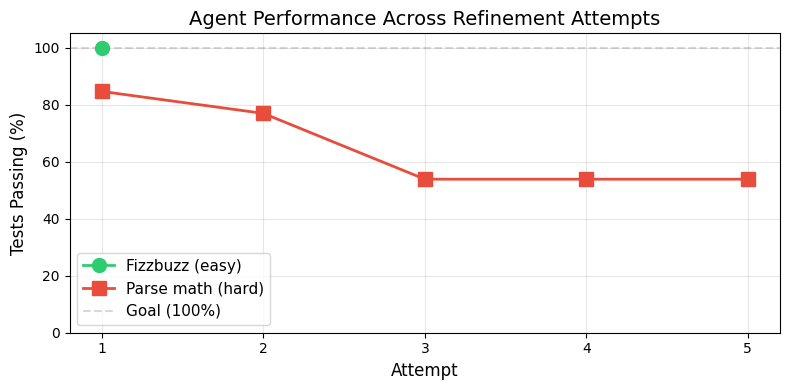

In [ ]:
# ── Plot 1: Pass rate over attempts (line chart) ──

fig, ax = plt.subplots(figsize=(8, 4))

# Fizzbuzz
fizz_attempts = [r[0] for r in fizz_rates]
fizz_pcts = [r[1] / r[2] * 100 for r in fizz_rates]
ax.plot(fizz_attempts, fizz_pcts, "o-", color="#2ecc71", linewidth=2,
        markersize=10, label="Fizzbuzz (easy)", zorder=3)

# Parse math
tricky_attempts = [r[0] for r in tricky_rates]
tricky_pcts = [r[1] / r[2] * 100 for r in tricky_rates]
ax.plot(tricky_attempts, tricky_pcts, "s-", color="#e74c3c", linewidth=2,
        markersize=10, label="Parse math (hard)", zorder=3)

ax.set_xlabel("Attempt", fontsize=12)
ax.set_ylabel("Tests Passing (%)", fontsize=12)
ax.set_title("Agent Performance Across Refinement Attempts", fontsize=14)
ax.set_xticks(range(1, 6))
ax.set_ylim(0, 105)
ax.axhline(y=100, color="gray", linestyle="--", alpha=0.3, label="Goal (100%)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

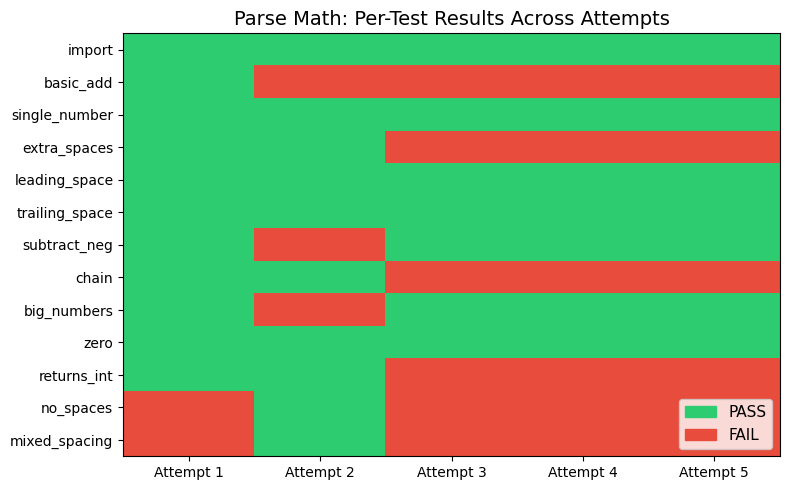

In [ ]:
# ── Plot 2: Per-test heatmap for parse_math (shows regression) ──

# Collect per-test pass/fail across attempts
test_names = []
test_grid = []

for h in history_tricky:
    stdout = h["test_result"]["stdout"]
    attempt_results = {}
    for line in stdout.split("\n"):
        line = line.strip()
        if line.startswith("[PASS]"):
            name = line.split("]")[1].strip().rstrip(":")
            attempt_results[name] = 1
        elif line.startswith("[FAIL]"):
            name = line.split("]")[1].strip().split(":")[0].strip()
            attempt_results[name] = 0

    if not test_names:
        test_names = list(attempt_results.keys())

    test_grid.append([attempt_results.get(t, 0) for t in test_names])

import numpy as np
grid = np.array(test_grid).T  # tests × attempts

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.colors.ListedColormap(["#e74c3c", "#2ecc71"])
ax.imshow(grid, cmap=cmap, aspect="auto", interpolation="nearest")

ax.set_xticks(range(len(history_tricky)))
ax.set_xticklabels([f"Attempt {h['attempt']}" for h in history_tricky])
ax.set_yticks(range(len(test_names)))
ax.set_yticklabels(test_names, fontsize=10)
ax.set_title("Parse Math: Per-Test Results Across Attempts", fontsize=14)

# Legend
pass_patch = mpatches.Patch(color="#2ecc71", label="PASS")
fail_patch = mpatches.Patch(color="#e74c3c", label="FAIL")
ax.legend(handles=[pass_patch, fail_patch], loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

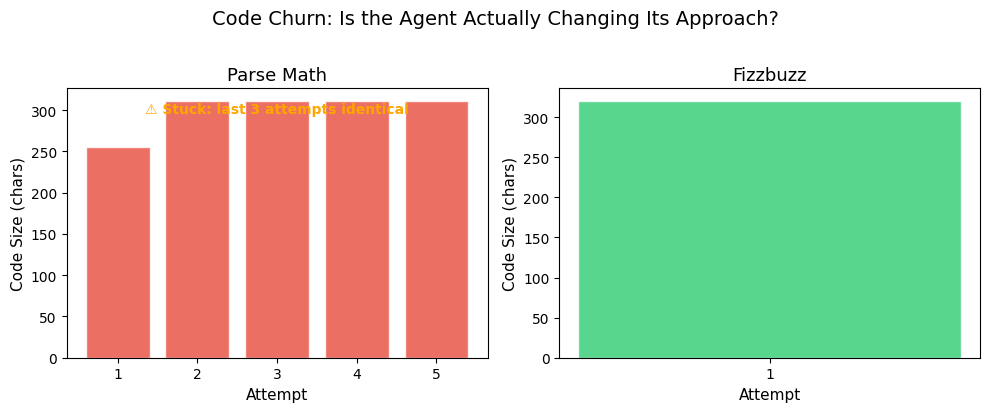

In [ ]:
# ── Plot 3: Code churn (did the agent actually change its code?) ──

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, hist, title, color in [
    (axes[0], history_tricky, "Parse Math", "#e74c3c"),
    (axes[1], history, "Fizzbuzz", "#2ecc71")
]:
    sizes = [len(h["code"]) for h in hist]
    attempts = [h["attempt"] for h in hist]
    ax.bar(attempts, sizes, color=color, alpha=0.8, edgecolor="white")
    ax.set_xlabel("Attempt", fontsize=11)
    ax.set_ylabel("Code Size (chars)", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.set_xticks(attempts)

    # Check if code is stuck (last N attempts identical)
    codes = [h["code"] for h in hist]
    if len(codes) > 1:
        stuck_count = 1
        for k in range(len(codes) - 1, 0, -1):
            if codes[k] == codes[k - 1]:
                stuck_count += 1
            else:
                break
        if stuck_count > 1:
            ax.text(0.5, 0.95, f"⚠ Stuck: last {stuck_count} attempts identical",
                    transform=ax.transAxes, ha="center", va="top",
                    fontsize=10, color="orange", fontweight="bold")

fig.suptitle("Code Churn: Is the Agent Actually Changing Its Approach?",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Analysis: The Refinement Trajectory

The `parse_math` task reveals two critical failure modes in a flat (non-hierarchical) agent:

### 1. Regression (Attempt 1 → 2 → 3)
| Attempt | Passed | What happened |
|---------|--------|---------------|
| 1       | 11/13  | Used `split()` — works for spaced input, fails on `"1+2"` |
| 2       | 10/13  | Tried to handle no-space — but broke subtraction with spaces |
| 3-5     | 7/13   | Overcorrected, now fails on most inputs. Stuck in a loop. |

The agent **regressed** — each fix introduced new bugs. Without a mechanism to
track *which constraints were previously satisfied*, it can't preserve past progress.

### 2. No Strategic Backtracking
In attempts 3–5, the agent produced **identical code** (311 chars each time).
The feedback tells it *what* failed, but not *why* its approach is wrong.
It has no way to say: "my tokenization strategy is fundamentally broken,
let me try regex instead of split."

### What OpenTAMP Would Add
In the hierarchical planning framework:
- The **symbolic layer** would track which test groups pass/fail as *predicates*
- A regression (previously-passing test now fails) would trigger a **replan**,
  not just a retry
- The planner could try **structurally different actions**: "use regex parsing"
  vs "use split-based parsing" vs "use character-by-character scanning"
- **Belief tracking** would maintain a distribution over which parsing strategy
  is most likely to satisfy all constraints simultaneously

## Summary & Next Steps

### What This Prototype Demonstrates
This notebook implements a minimal coding agent with three components:
1. **Code generation** (DeepSeek-Coder-6.7B) — the continuous/motion layer
2. **Hidden test harness** — the environment providing partial observations
3. **LLM-as-Judge** — goal predicate evaluation

### Key Findings
| Task | Result | Failure Mode |
|------|--------|-------------|
| Fizzbuzz | ✅ 9/9, attempt 1 | None — task too simple |
| Merge intervals | ❌ 11/12, stuck | Repeated identical attempts (no diversity) |
| Parse math | ❌ 7/13, regressed | Fixes broke passing tests (no constraint memory) |

### Why Hierarchical Planning (SWE-TAMP) Is Needed
The flat agent loop has no mechanism for:
- **Strategic diversity** — trying fundamentally different approaches after failure
- **Constraint memory** — remembering which tests previously passed and protecting them
- **Failure abstraction** — understanding *why* something fails, not just *that* it fails

These are exactly what OpenTAMP's hierarchical architecture provides:
- The **symbolic layer** (Fast Downward) can select different action skeletons
- **Preconditions and effects** track which constraints are satisfied
- **Backtracking** propagates failure information upward to force replanning

### Next Steps
1. Define the SWE-TAMP domain (actions, predicates, objects) in OpenTAMP format
2. Integrate with the ToM-SWE benchmark for standardized evaluation
3. Compare flat agent vs. hierarchical agent on the same task suite